In [2]:
# Cài đặt nếu máy chưa có: !pip install pandas matplotlib seaborn numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

# Cấu hình phong cách biểu đồ cho chuyên nghiệp (chuẩn viết báo khoa học)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Tạo thư mục lưu biểu đồ nếu chưa có
os.makedirs('../outputs', exist_ok=True)

## EDA cho NIH

In [3]:
# Đọc dữ liệu NIH
nih_csv_path = '../data/raw/nih-chest-xray/Data_Entry_2017.csv'
df_nih = pd.read_csv(nih_csv_path)

print(f"Tổng số ảnh NIH: {len(df_nih)}")

# Tách nhãn và đếm tần suất
all_nih_labels = []
for labels in df_nih['Finding Labels']:
    all_nih_labels.extend(labels.split('|'))

nih_counts = Counter(all_nih_labels)

# Tách riêng nhãn 'No Finding' (Không có bệnh) để phân tích
no_finding_count = nih_counts['No Finding']
del nih_counts['No Finding'] # Xóa khỏi dict để vẽ các bệnh lý cho rõ

# Chuyển thành DataFrame để dễ vẽ
df_nih_counts = pd.DataFrame.from_dict(nih_counts, orient='index', columns=['Count']).reset_index()
df_nih_counts.columns = ['Disease', 'Count']
df_nih_counts = df_nih_counts.sort_values('Count', ascending=False)

Tổng số ảnh NIH: 112120


C:\Users\admin\AppData\Local\Temp\ipykernel_18332\3695976528.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Disease', y='Count', data=df_nih_counts, palette='magma')


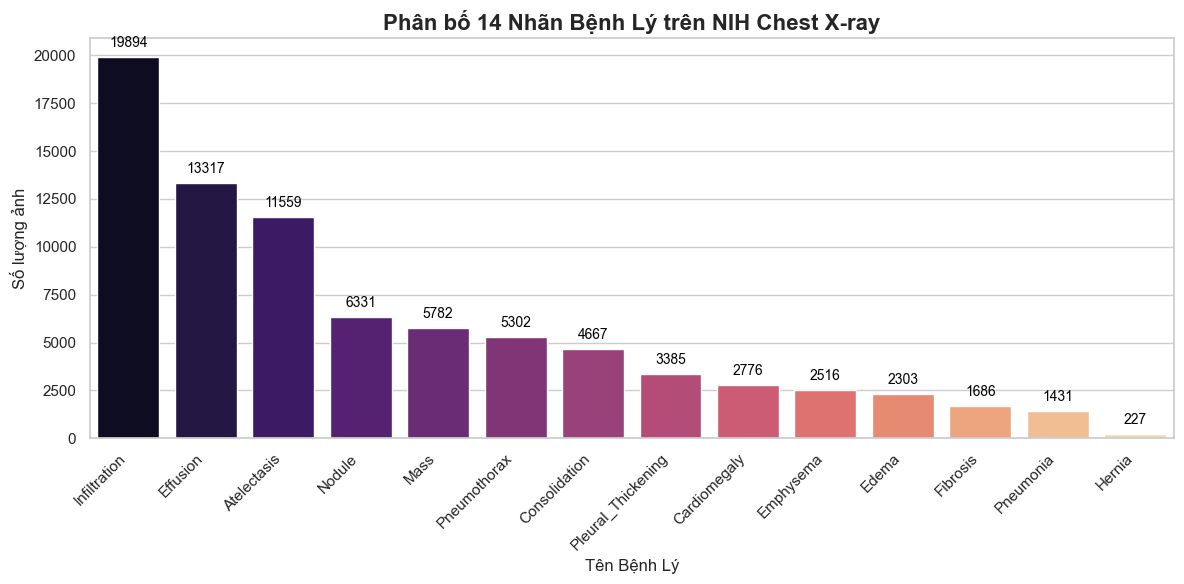

In [4]:
# Vẽ biểu đồ phân bố nhãn bệnh NIH
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Disease', y='Count', data=df_nih_counts, palette='magma')
plt.title('Phân bố 14 Nhãn Bệnh Lý trên NIH Chest X-ray', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Số lượng ảnh')
plt.xlabel('Tên Bệnh Lý')

# Thêm số lượng trên đỉnh mỗi cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('../outputs/nih_distribution.png', dpi=300)
plt.show()


In [5]:
# In ra phân tích độ mất cân bằng
max_disease = df_nih_counts.iloc[0]
min_disease = df_nih_counts.iloc[-1]
print(f"\nPhân tích mức độ mất cân bằng NIH:")
print(f"- Số ảnh KHÔNG BỆNH (No Finding): {no_finding_count} ({no_finding_count/len(df_nih)*100:.1f}%)")
print(f"- Bệnh phổ biến nhất: {max_disease['Disease']} với {max_disease['Count']} ảnh.")
print(f"- Bệnh hiếm gặp nhất: {min_disease['Disease']} chỉ có {min_disease['Count']} ảnh.")
print(f"=> Tỷ lệ chênh lệch giữa nhãn đa số và thiểu số là: {max_disease['Count'] // min_disease['Count']} lần!")


Phân tích mức độ mất cân bằng NIH:
- Số ảnh KHÔNG BỆNH (No Finding): 60361 (53.8%)
- Bệnh phổ biến nhất: Infiltration với 19894 ảnh.
- Bệnh hiếm gặp nhất: Hernia chỉ có 227 ảnh.
=> Tỷ lệ chênh lệch giữa nhãn đa số và thiểu số là: 87 lần!


## EDA cho VinBigData

In [6]:
# Đọc dữ liệu VinBigData
vin_csv_path = '../data/raw/vinbigdata-chest-xray/train.csv'
df_vin_raw = pd.read_csv(vin_csv_path)

print(f"Tổng số dòng ban đầu (bao gồm bbox): {len(df_vin_raw)}")

# Gom nhóm theo image_id để lấy nhãn phân lớp (Image-level classification)
# Nếu 1 ảnh có nhiều bác sĩ đánh giá ra cùng 1 bệnh, ta chỉ tính 1 lần (dùng set)
df_vin_grouped = df_vin_raw.groupby('image_id')['class_name'].apply(lambda x: list(set(x))).reset_index()

print(f"Tổng số ảnh thực tế sau khi gom nhóm: {len(df_vin_grouped)}")

# Đếm tần suất các nhãn
all_vin_labels = []
for labels in df_vin_grouped['class_name']:
    all_vin_labels.extend(labels)

vin_counts = Counter(all_vin_labels)

# Tách riêng 'No finding'
vin_no_finding_count = vin_counts['No finding']
del vin_counts['No finding']

df_vin_counts = pd.DataFrame.from_dict(vin_counts, orient='index', columns=['Count']).reset_index()
df_vin_counts.columns = ['Disease', 'Count']
df_vin_counts = df_vin_counts.sort_values('Count', ascending=False)

Tổng số dòng ban đầu (bao gồm bbox): 67914
Tổng số ảnh thực tế sau khi gom nhóm: 15000


C:\Users\admin\AppData\Local\Temp\ipykernel_18332\1363517741.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Disease', y='Count', data=df_vin_counts, palette='viridis')


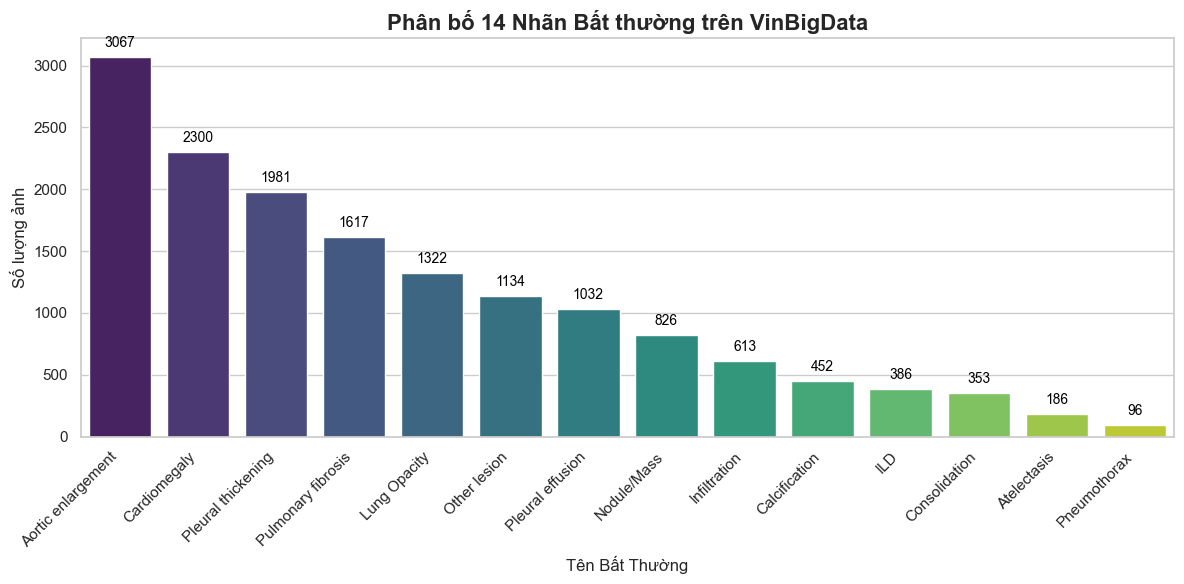

In [7]:
# Vẽ biểu đồ phân bố VinBigData
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Disease', y='Count', data=df_vin_counts, palette='viridis')
plt.title('Phân bố 14 Nhãn Bất thường trên VinBigData', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Số lượng ảnh')
plt.xlabel('Tên Bất Thường')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('../outputs/vin_distribution.png', dpi=300)
plt.show()

In [8]:
# In ra phân tích VinBigData
v_max = df_vin_counts.iloc[0]
v_min = df_vin_counts.iloc[-1]
print(f"\nPhân tích mức độ mất cân bằng VinBigData:")
print(f"- Số ảnh KHÔNG BỆNH (No finding): {vin_no_finding_count} ({vin_no_finding_count/len(df_vin_grouped)*100:.1f}%)")
print(f"- Bệnh phổ biến nhất: {v_max['Disease']} ({v_max['Count']} ảnh).")
print(f"- Bệnh hiếm gặp nhất: {v_min['Disease']} ({v_min['Count']} ảnh).")


Phân tích mức độ mất cân bằng VinBigData:
- Số ảnh KHÔNG BỆNH (No finding): 10606 (70.7%)
- Bệnh phổ biến nhất: Aortic enlargement (3067 ảnh).
- Bệnh hiếm gặp nhất: Pneumothorax (96 ảnh).


## Tạo file CSV chuẩn hóa cho DataLoader

In [9]:
# Tạo ONE-HOT CSV cho NIH
nih_classes = sorted(list(df_nih_counts['Disease']))

# Tạo các cột bằng 0
for c in nih_classes:
    df_nih[c] = 0

# Điền 1 nếu có bệnh
for idx, row in df_nih.iterrows():
    labels = row['Finding Labels'].split('|')
    for label in labels:
        if label in nih_classes:
            df_nih.at[idx, label] = 1

# Tạo cột đường dẫn tuyệt đối (trỏ vào thư mục ảnh đã gom)
df_nih['image_path'] = df_nih['Image Index'].apply(lambda x: f"data/processed/nih_512x512/images/{x}")

# Lưu lại các cột cần thiết
cols_to_keep = ['Image Index', 'image_path'] + nih_classes
df_nih_final = df_nih[cols_to_keep]
df_nih_final.to_csv('../data/processed/nih_labels.csv', index=False)
print("✅ Đã lưu file chuẩn cho NIH: data/processed/nih_labels.csv")

✅ Đã lưu file chuẩn cho NIH: data/processed/nih_labels.csv


In [10]:
# Tạo ONE-HOT CSV cho VinBigData
vin_classes = sorted(list(df_vin_counts['Disease']))

# Tạo cột 0
for c in vin_classes:
    df_vin_grouped[c] = 0

# Điền 1 nếu có bệnh
for idx, row in df_vin_grouped.iterrows():
    labels = row['class_name']
    for label in labels:
        if label in vin_classes:
            df_vin_grouped.at[idx, label] = 1

# Tạo cột đường dẫn (lưu ý vinbigdata gốc ta đổi đuôi thành .png rồi)
df_vin_grouped['image_path'] = df_vin_grouped['image_id'].apply(lambda x: f"data/processed/vin_512x512/train/{x}.png")

cols_to_keep_vin = ['image_id', 'image_path'] + vin_classes
df_vin_grouped = df_vin_grouped[cols_to_keep_vin]
df_vin_grouped.to_csv('../data/processed/vin_labels.csv', index=False)
print("✅ Đã lưu file chuẩn cho VinBigData: data/processed/vin_labels.csv")

✅ Đã lưu file chuẩn cho VinBigData: data/processed/vin_labels.csv
